In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, time
import re

/tmp/ipykernel_2605823/66975067.py:75: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2605823/66975067.py:75: UserWarning: Glyph 36234 (\N{CJK UNIFIED IDEOGRAPH-8D8A}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2605823/66975067.py:75: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2605823/66975067.py:75: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2605823/66975067.py:75: UserWarning: Glyph 28171 (\N{CJK UNIFIED IDEOGRAPH-6E0B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2605823/66975067.py:75: UserWarning: Glyph 28382 (\N{CJK UNIFIED IDEOGRAPH-6EDE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2605823/66975067.py:75: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from current font.
  plt.tight_lay

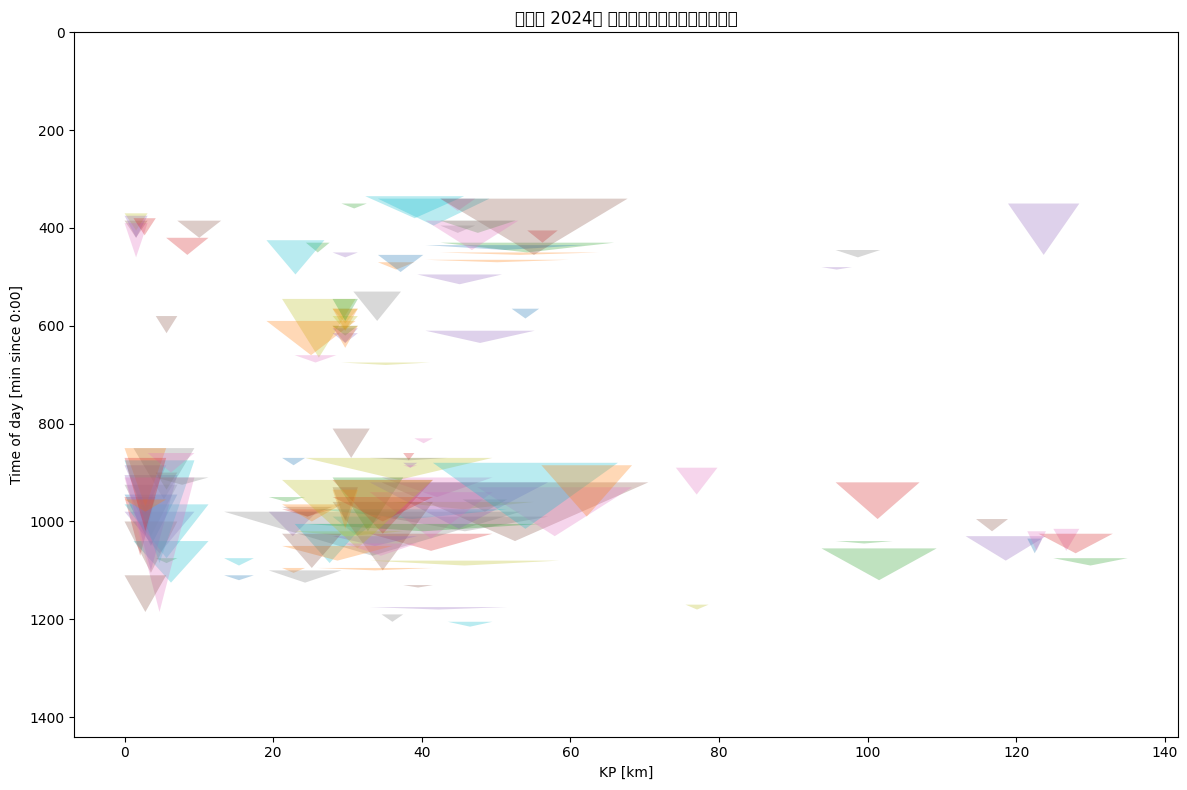

In [2]:


# === 1. 读取 Excel ===
file_path = "./関越2024_cleaned.xlsx"  # 如果文件放在其他位置，请修改为你的实际路径
df = pd.read_excel(file_path)

# === 2. 辅助函数：解析ピーク時刻/発生時刻 ===
def parse_hhmm_or_int(val):
    """
    支持："06:35:00" / "6:35" / 635 / 905 → datetime.time
    """
    if pd.isnull(val):
        return None

    # 1) 已经是 datetime 或 time 对象
    if isinstance(val, (datetime, time)):
        return val.time() if isinstance(val, datetime) else val

    # 2) 字符串 "HH:MM[:SS]"
    if isinstance(val, str):
        for fmt in ("%H:%M:%S", "%H:%M"):
            try:
                return datetime.strptime(val, fmt).time()
            except ValueError:
                continue
        # 落到纯数字
        val = val.strip()

    # 3) 纯数字（可能是 int/float/数字字符串）
    val_str = str(int(float(val)))
    if len(val_str) == 3:   # e.g. 635
        h, m = int(val_str[0]), int(val_str[1:])
    elif len(val_str) == 4: # e.g. 1235
        h, m = int(val_str[:2]), int(val_str[2:])
    else:                   # 长度 1~2 → 0~23 点整
        h, m = int(val_str), 0
    return time(h, m)

def t2min(t: time) -> int:
    return t.hour * 60 + t.minute

# === 3. 解析时间列 ===
df["発生_t"] = df["発生時刻"].apply(parse_hhmm_or_int)
df["ピーク_t"] = df["ピーク時刻"].apply(parse_hhmm_or_int)

# === 4. 生成三角形顶点 ===
triangles = []   # 每个元素: [(x0, y0), (x1, y1), (x2, y2)]
for _, row in df.iterrows():
    if pd.isnull(row["発生_t"]) or pd.isnull(row["ピーク_t"]):
        continue

    # 左右 KP（横坐标）
    x_left  = row["発生Ｋｐ"]                            # 拥堵起点
    width   = row["ピーク長"]                           # ピーク時の渋滞長 [km]
    x_right = x_left + width                           # 拥堵终点
    apex_x  = x_left + width / 2                       # 顶点在中点 (简单假设)

    # 上下时间（纵坐标, 单位 min）
    y_base  = t2min(row["発生_t"])                      # 拥堵开始
    y_apex  = t2min(row["ピーク_t"])                    # 拥堵峰值

    triangles.append([(apex_x, y_apex), (x_left, y_base), (x_right, y_base)])

# === 5. 绘图 ===
fig, ax = plt.subplots(figsize=(12, 8))
for tri in triangles:
    xs, ys = zip(*tri)
    ax.fill(xs, ys, alpha=0.3)                         # 不显式指定颜色 (= Matplotlib 默认色)

# 轴信息
ax.set_xlabel("KP [km]")
ax.set_ylabel("Time of day [min since 0:00]")
ax.set_title("関越道 2024年 渋滞イベント（三角形表示）")
ax.set_ylim(0, 24*60)
ax.invert_yaxis()                                      # 上方=凌晨, 下方=深夜

plt.tight_layout()
plt.show()